In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import pandas as pd
import muon as mu
import scanpy as sc
import scirpy as ir
np.random.seed(42)
import random
random.seed(42)

import sys
sys.path.append("/ihome/ylee/yiz133/Code/Data processing/functions")
import importlib
import mdata_utils 
import TCR_embedings

2026-03-23 16:52:08.425243: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-23 16:52:08.425629: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-23 16:52:08.492088: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-23 16:52:12.046700: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

In [2]:
path = "/ix1/ylee/Yifan_Zhang/Code_data/data_EAE/anndata/"

In [3]:
mdata_ori = mu.read(path + "annotated_T_DE2500.h5mu")

In [43]:
mdata = mdata_ori

In [44]:
mdata['gex'].obs['mouse_id'].value_counts()

mouse_id
6_3    9767
6_2    8689
6_4    8524
6_1    7239
5_3    6228
5_4    6041
5_7    4498
5_5    4220
5_6    3938
5_8    3746
Name: count, dtype: int64

In [45]:
mouse_ids = list(set(mdata.mod['gex'].obs['mouse_id'].tolist()))
mouse_ids

['5_5', '6_2', '6_4', '5_7', '5_6', '5_3', '6_3', '6_1', '5_4', '5_8']

In [46]:
selected_id = '6_3'
mdata = mdata_utils.sync_mdata_obs(mdata)
mdata = mdata[mdata['gex'].obs['mouse_id'].isin([selected_id])].copy()
mdata['gex'].obs['manual_cell_type'].value_counts()

manual_cell_type
CD4+ T    4094
CD8+ T    3029
Treg      1541
Name: count, dtype: int64

In [47]:
mdata = mdata[~mdata['gex'].obs['manual_cell_type'].isin(['multiplet','Myeloid'])].copy()
mdata.mod['gex'] = mdata.mod['gex'][mdata.mod['gex'].obs['manual_cell_type'].notna()].copy()
# mdata = mdata[mdata['gex'].obs['manual_cell_type'].isin(['CD8+ T'])].copy()

mdata = mdata_utils.sync_mdata_obs(mdata)
mdata

MuData object with n_obs × n_vars = 3029 × 2500
  obs:	'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_HTO', 'nFeature_HTO', 'HTO_maxID', 'HTO_secondID', 'HTO_margin', 'HTO_classification', 'HTO_classification.global', 'hash.ID', 'percent.mt', 'integrated_nn_res.2', 'seurat_clusters', 'level_2_clusters', 'manual_cell_type', 'run_num', 'sample'
  2 modalities
    gex:	3029 x 2500
      obs:	'mouse_id', 'date', 'tissue', 'sample', 'mouse_BC', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'n_counts', 'manual_cell_type', 'leiden', 'Auto', 'IFN_stim_score', 'Activation_score', 'Exhaust_score', 'Mem_score', 'cell_type_annotation', 'best_label'
      var:	'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
      uns:	'Auto_colors', 'best_label_colors', 'cell_type_annotation_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'mouse_id_colors', 'neighbors', 'pca', 'rank_genes_groups', 'tissue_colors', 'umap'
      obsm:	'X_pca', 'X_umap'
      varm:	'PCs'
      obsp:	'connectivities', 'distances'
    airr:	3029 x 0
      obsm:	'airr'

In [48]:
ir.pp.index_chains(mdata)
ir.tl.chain_qc(mdata)

# by nucleotide acid seq
ir.pp.ir_dist(mdata)
ir.tl.define_clonotypes(mdata, receptor_arms="all", dual_ir="primary_only")
# ir.tl.clonotype_network(mdata, min_cells=10)

meta_airr = ir.get.airr(mdata['airr'], ["cdr3_aa", "v_call", "j_call"] ,  ('VJ_1', 'VDJ_1'))
mdata.obs = mdata.obs.join(meta_airr)
mdata.update()

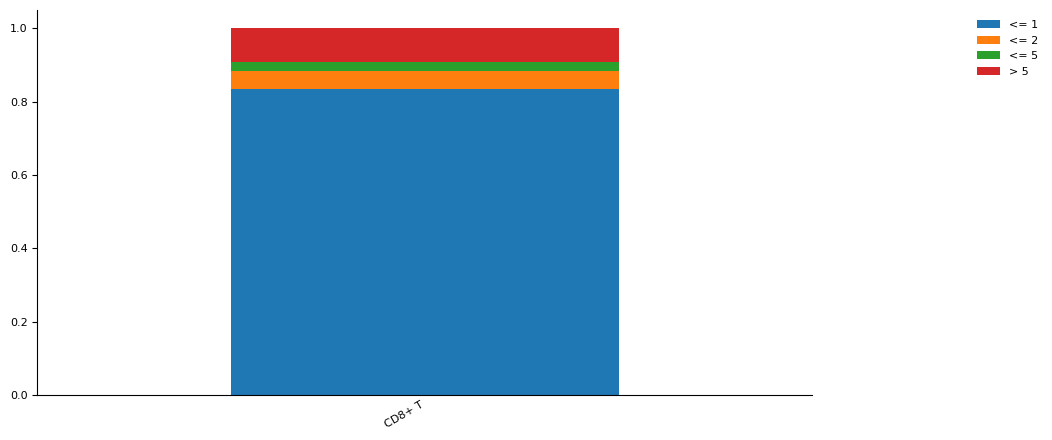

In [49]:
fig, ax = plt.subplots(figsize=(10, 5))
mdata['airr'].obs['manual_cell_type'] = mdata.obs['manual_cell_type']
mdata['airr'].obs['tissue'] = mdata['gex'].obs['tissue']

_ = ir.pl.clonal_expansion(
    mdata, 
    target_col= "clone_id",
    groupby= "manual_cell_type",  # Use the new combined column
    breakpoints=(1, 2, 5), 
    ax = ax
    #normalize=False
)

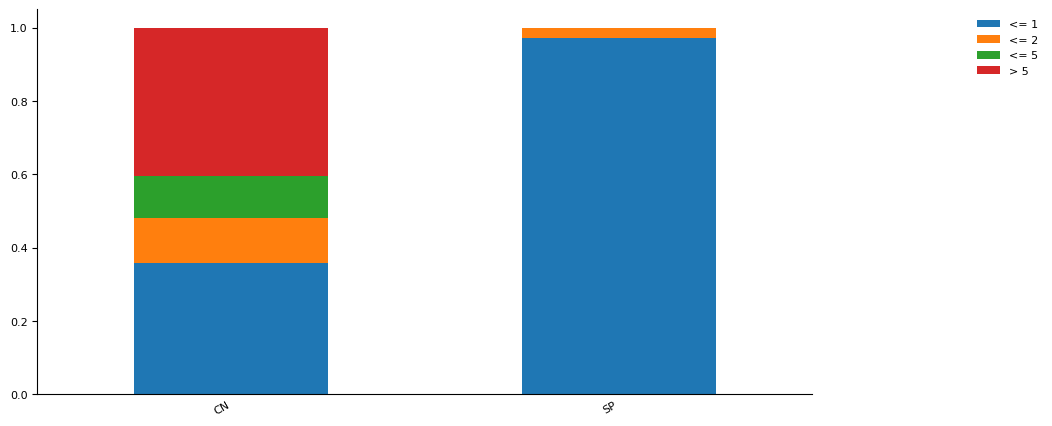

In [50]:
fig, ax = plt.subplots(figsize=(10, 5))
_ = ir.pl.clonal_expansion(
    mdata, 
    target_col= "clone_id",
    groupby= "tissue",  # Use the new combined column
    breakpoints=(1, 2, 5), 
    ax = ax
    #normalize=False
)

In [51]:
clone_thresh = 2
mdata.obs['cloned'] = mdata['airr'].obs['clone_id_size'] >= clone_thresh

# Check if appear in two tissues
mdata_cloned = mdata[mdata.obs['cloned']]
clone_tissue_df = mdata_cloned['airr'].obs[['clone_id']].join(mdata_cloned['gex'].obs['tissue'])
clone_tissue_counts = clone_tissue_df.groupby('clone_id')['tissue'].nunique()
multi_tissue_clones = clone_tissue_counts[clone_tissue_counts > 1].index
mdata.obs['in_two_tissue'] = mdata['airr'].obs['clone_id'].isin(multi_tissue_clones)

mdata.obs['in_two_tissue'].value_counts()

in_two_tissue
False    3027
True        2
Name: count, dtype: int64

In [55]:
mdata_target = mdata[mdata['gex'].obs['manual_cell_type'].isin(['CD4+ T'])].copy()
# mdata_target = mdata[mdata.obs['in_two_tissue'] == True]
mdata_target

In [56]:
mdata_target['gex'].obs['manual_cell_type'].value_counts()

manual_cell_type
CD8+ T    3029
Name: count, dtype: int64

In [57]:
sc.pp.pca(mdata_target["gex"], svd_solver="arpack", n_comps=50)
sc.pp.neighbors(mdata_target["gex"], n_neighbors = 50)
sc.tl.umap(mdata_target["gex"], min_dist=0.5, spread=1.0)

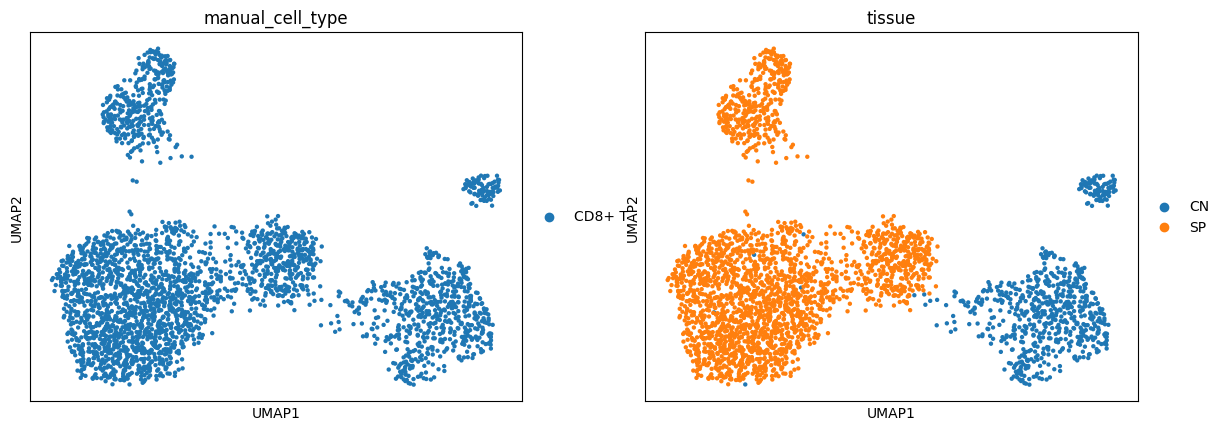

In [58]:
sc.pl.umap(mdata_target["gex"], color=["manual_cell_type", "tissue", ], ncols = 2)

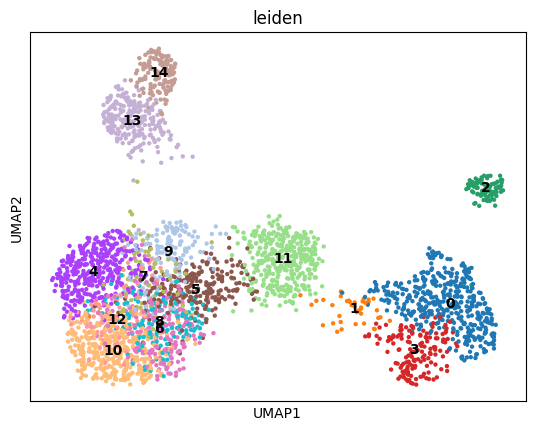

In [59]:
sc.tl.leiden(mdata_target["gex"], resolution = 2, n_iterations=-1, flavor = 'igraph')
sc.pl.umap(mdata_target["gex"], color="leiden", legend_loc="on data")

In [60]:
from cluster_annotation import *
# ============================================================
# DICT 1: CD4+ T cell SUBTYPES (lineage identity)
# Stable, transcription-factor-driven lineage commitments
# ============================================================
cd4_subtype_markers = {

    'CD4_Naive': [
        'Sell', 'Ccr7', 'Il7r', 'Tcf7',
        'Tbx21-', 'Gata3-', 'Rorc-', 'Bcl6-', 'Foxp3-'
    ],
    'CD4_TH1': [
        'Tbx21', 'Ifng', 'Cxcr3', 'Stat1',
        'Gata3-', 'Rorc-', 'Bcl6-', 'Il4-', 'Il17a-'
    ],
    'CD4_TH2': [
        'Gata3', 'Il4', 'Il5', 'Il13', 'Stat6',
        'Tbx21-', 'Rorc-', 'Ifng-'
    ],
    'CD4_TH17': [
        'Rorc', 'Il17a', 'Il23r', 'Stat3',
        'Tbx21-', 'Gata3-', 'Foxp3-', 'Ifng-'
    ],
    'CD4_TFH': [
        'Bcl6', 'Cxcr5', 'Icos', 'Il21', 'Pdcd1',
        'Sell-', 'Ccr7-', 'Tbx21-'
    ],
    'CD4_Treg': [
        'Foxp3', 'Il2ra', 'Ikzf2', 'Cd44',
        'Il17a-', 'Ifng-', 'Bcl6-'
    ],
}


# ============================================================
# DICT 2: CD4+ T cell STATES (functional/positional states)
# Can apply across subtypes; defined by migration, residency,
# activation history, or exhaustion
# ============================================================
cd4_state_markers = {

    # --- Circulating memory states ---
    'CD4_TCM': [
        'Ccr7', 'Sell', 'Tcf7', 'Il2', 'Cd27',
        'S1pr1-', 'Klf2-', 'Ly6c2-'
    ],
    'CD4_TEM': [
        'Ly6c2', 'Cx3cr1', 'Ifng',
        'Ccr7-', 'Sell-', 'Tcf7-'
    ],

    # --- Tissue-resident memory states ---
    'CD4_TRM': [                         # pan-TRM, tissue-generic
        'Cd69', 'Cxcr6',
        'S1pr1-', 'Klf2-', 'Ccr7-', 'Sell-'
    ],
    # --- Exhaustion / chronic stimulation states ---
    'CD4_Exhausted': [
        'Pdcd1', 'Lag3', 'Ctla4', 'Tox', 'Havcr2',
        'Il2-', 'Ifng-', 'Tcf7-'
    ],
    # --- Proliferating ---
    'CD4_Proliferating': [
        'Mki67', 'Top2a', 'Pcna', 'Stmn1', 'Cdk1',
    ],
}

In [61]:
# plot_umap_for_gene_dict(mdata_target['gex'], cd4_state_markers, show=True, save=False)

In [62]:
# Step 1: annotate lineage identity
subtype_scores, subtype_labels = score_leiden_clusters_by_marker_dict(
    mdata_target['gex'],
    cd4_subtype_markers,
    cell_type_annotation_col='cd4_subtype'
)

# Step 2: annotate functional/positional state
state_scores, state_labels = score_leiden_clusters_by_marker_dict(
    mdata_target['gex'],
    cd4_state_markers,
    cell_type_annotation_col='cd4_state'
)

# Both annotations coexist on the same cells
# e.g. cd4_subtype='CD4_TH1', cd4_state='CD4_TRM_TH1'

[Warning] 'CD4_Naive': genes not found in adata: ['Sell']
[Info] Scored 'CD4_Naive': 3 up, 5 down genes.
[Info] Scored 'CD4_TH1': 4 up, 5 down genes.
[Warning] 'CD4_TH2': genes not found in adata: ['Il5', 'Stat6']
[Info] Scored 'CD4_TH2': 3 up, 3 down genes.
[Warning] 'CD4_TH17': genes not found in adata: ['Stat3']
[Info] Scored 'CD4_TH17': 3 up, 4 down genes.
[Warning] 'CD4_TFH': genes not found in adata: ['Sell-']
[Info] Scored 'CD4_TFH': 5 up, 2 down genes.
[Info] Scored 'CD4_Treg': 4 up, 3 down genes.
[Warning] 'CD4_TCM': genes not found in adata: ['Sell', 'Cd27', 'S1pr1-']
[Info] Scored 'CD4_TCM': 3 up, 2 down genes.
[Warning] 'CD4_TEM': genes not found in adata: ['Sell-']
[Info] Scored 'CD4_TEM': 3 up, 2 down genes.
[Warning] 'CD4_TRM': genes not found in adata: ['S1pr1-', 'Sell-']
[Info] Scored 'CD4_TRM': 2 up, 2 down genes.
[Info] Scored 'CD4_Exhausted': 5 up, 3 down genes.
[Info] Scored 'CD4_Proliferating': 5 up, 0 down genes.


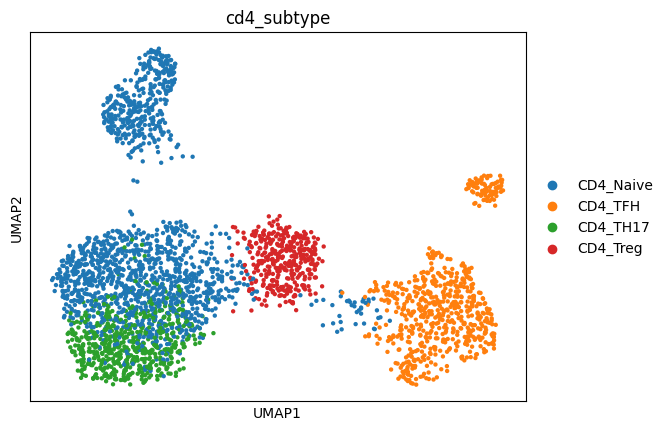

In [63]:
sc.pl.umap(mdata_target['gex'], color = 'cd4_subtype')

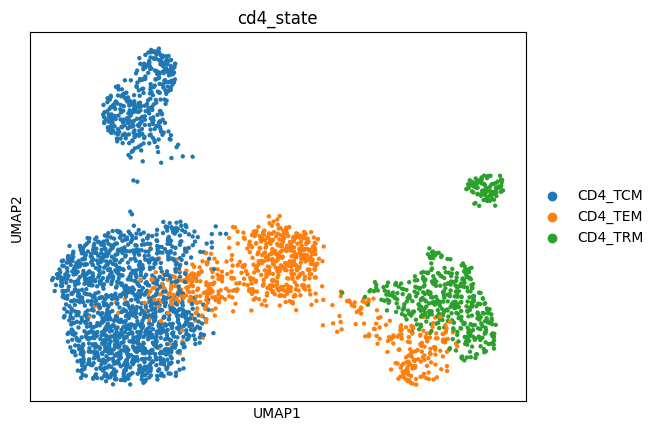

In [64]:
sc.pl.umap(mdata_target['gex'], color = 'cd4_state')

## CD8

In [ ]:
mdata_target = mdata[mdata['gex'].obs['manual_cell_type'].isin(['CD8+ T'])].copy()
# mdata_target = mdata[mdata.obs['in_two_tissue'] == True]
mdata_target

In [69]:
cd8_state_markers = {

    'CD8_Naive': [
        'Tcf7', 'Sell', 'Ccr7', 'Il7r', 'Cd28',
        'Tox-', 'Pdcd1-', 'Gzmb-', 'Cx3cr1-'
    ],

    'CD8_Tem': [                           # Tem + Temra merged — discriminated by state scores
        'Klrg1', 'Cx3cr1', 'Gzmb', 'Prf1', 'Tbx21',
        'Tcf7-', 'Ccr7-', 'Sell-', 'Tox-'
    ],

    'CD8_Teff': [                          # short-lived effector, antigen-driven burst
        'Gzmb', 'Prf1', 'Ifng', 'Tbx21', 'Cx3cr1',
        'Tcf7-', 'Tox-', 'Slamf6-', 'Il7r-'
    ],

    'CD8_Texh_prog': [                     # progenitor exhausted — key ICB-responsive pool
        'Tcf7', 'Slamf6', 'Xcl1', 'Cd28', 'Cxcr5',
        'Tox-', 'Havcr2-', 'Entpd1-', 'Cx3cr1-'
    ],

    'CD8_Texh_term': [                     # terminal — highest IR, lowest proliferative capacity
        'Tox', 'Havcr2', 'Lag3', 'Entpd1', 'Cd101',
        'Ccl3', 'Ccl4',
        'Tcf7-', 'Cx3cr1-', 'Cd28-', 'Gzmb-'
    ],

    'CD8_TRM': [                           # tissue residency — applies across subtypes
        'Cd69', 'Itgae', 'Cxcr6', 'Runx3',
        'S1pr1-', 'Klf2-', 'Ccr7-'
    ],

    'CD8_NK_like': [                       # NK-receptor Texh-int subpopulation
        'Klrb1c', 'Klrd1', 'Nkg7', 'Klrk1',
        'Tcf7-', 'Slamf6-'
    ],

    'CD8_Proliferating': [
        'Mki67', 'Top2a', 'Pcna', 'Cdk1',
    ],
}

UMAP: CD8_Naive (markers: ['Tcf7', 'Ccr7', 'Il7r', 'Cd28'])


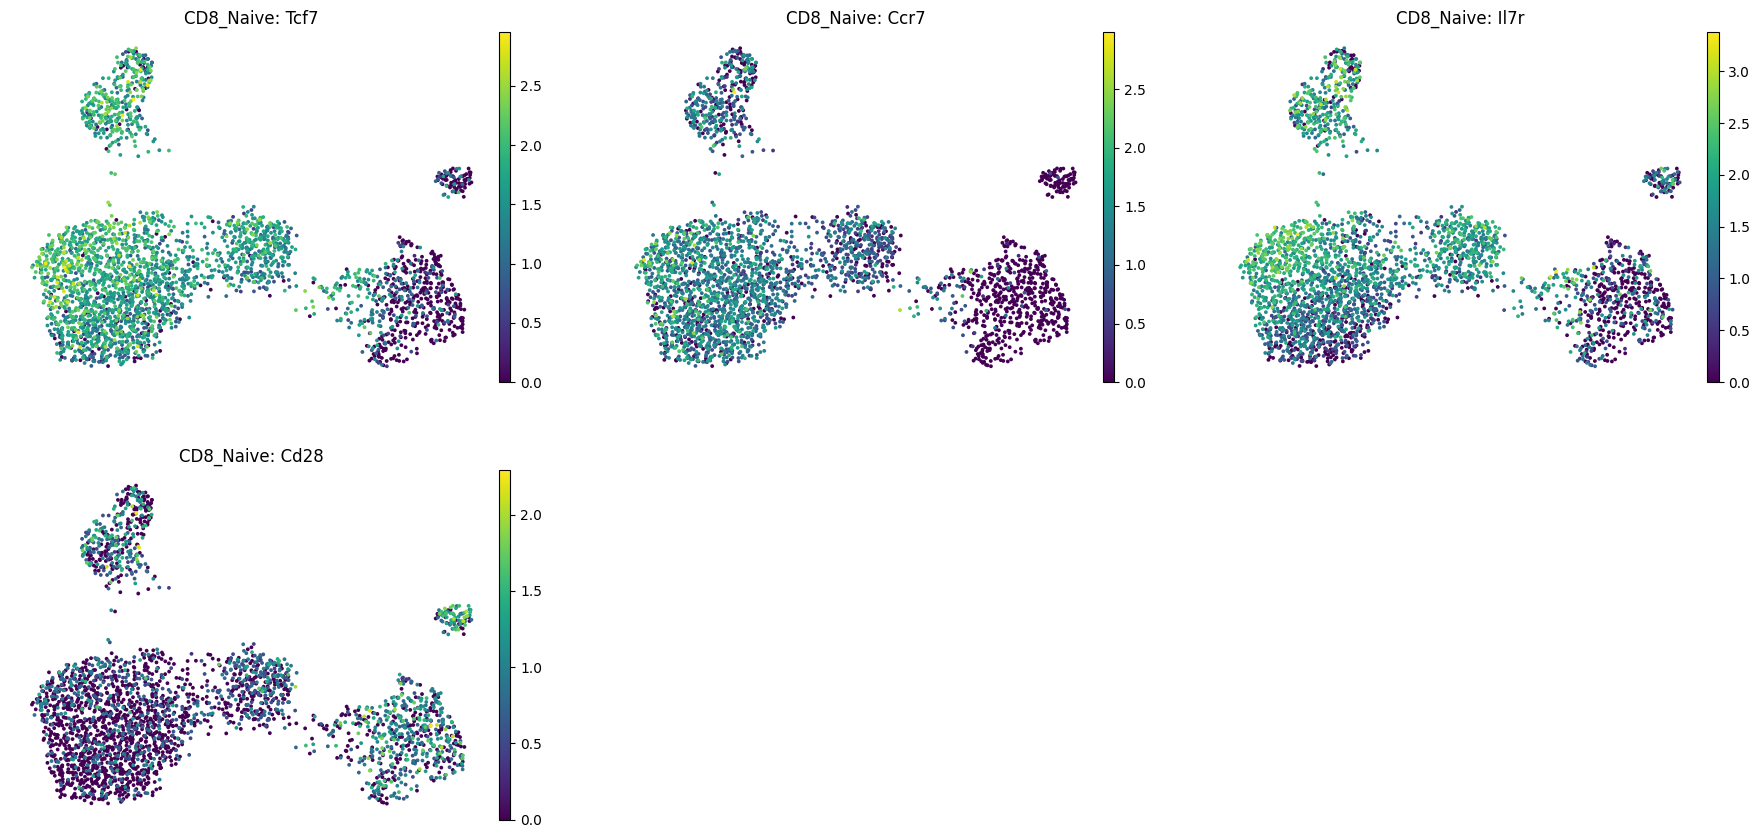

UMAP: CD8_Tem (markers: ['Klrg1', 'Cx3cr1', 'Gzmb', 'Prf1', 'Tbx21'])


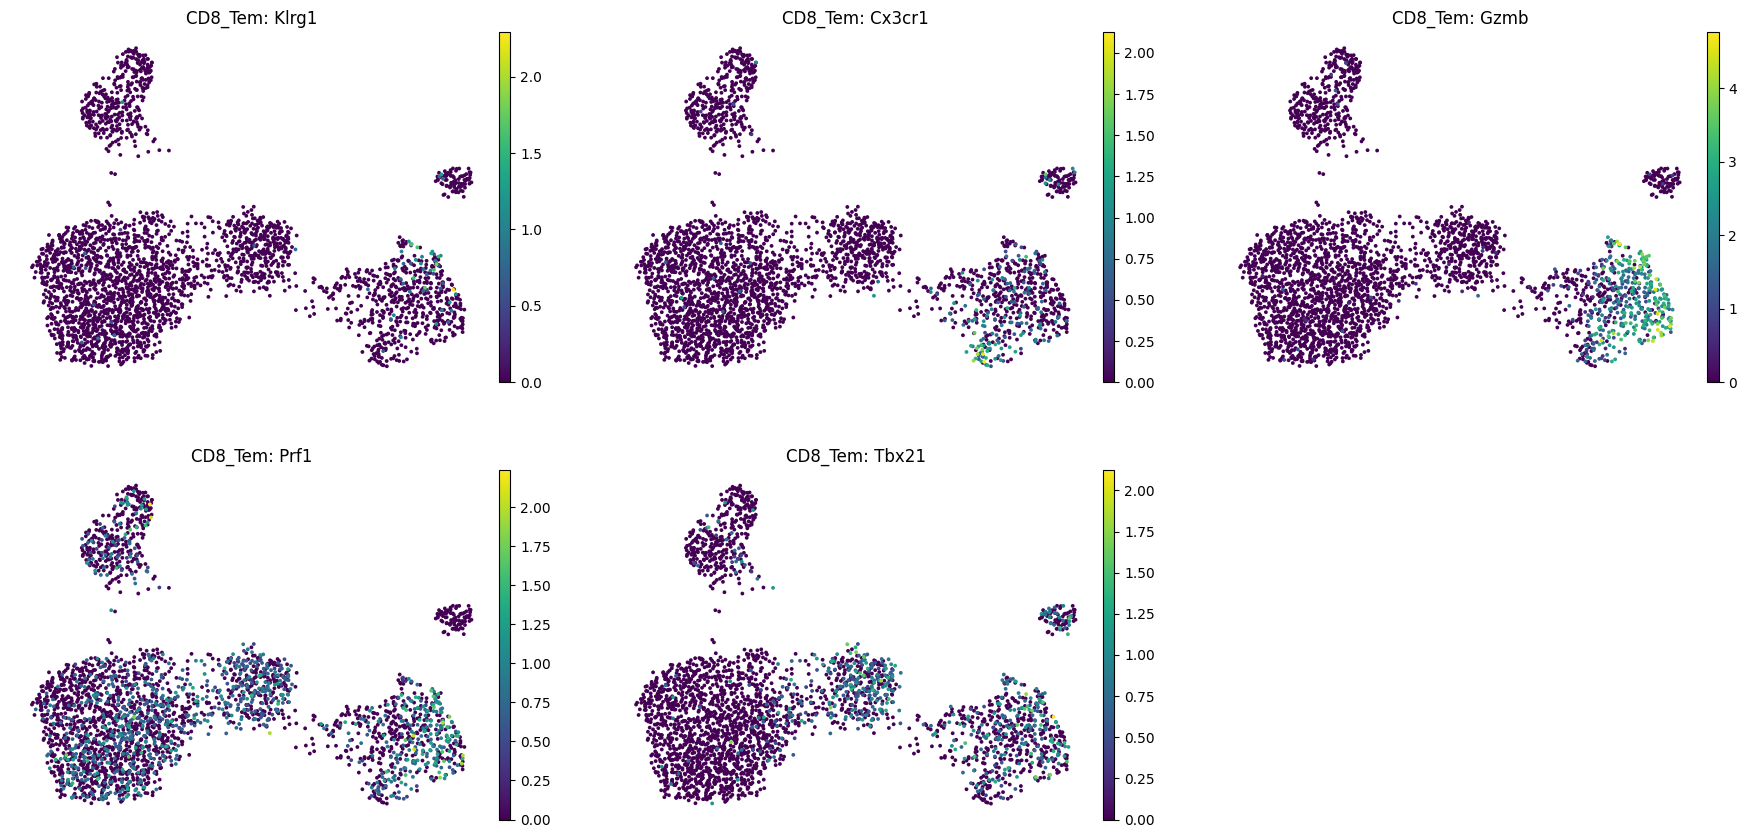

UMAP: CD8_Teff (markers: ['Gzmb', 'Prf1', 'Ifng', 'Tbx21', 'Cx3cr1'])


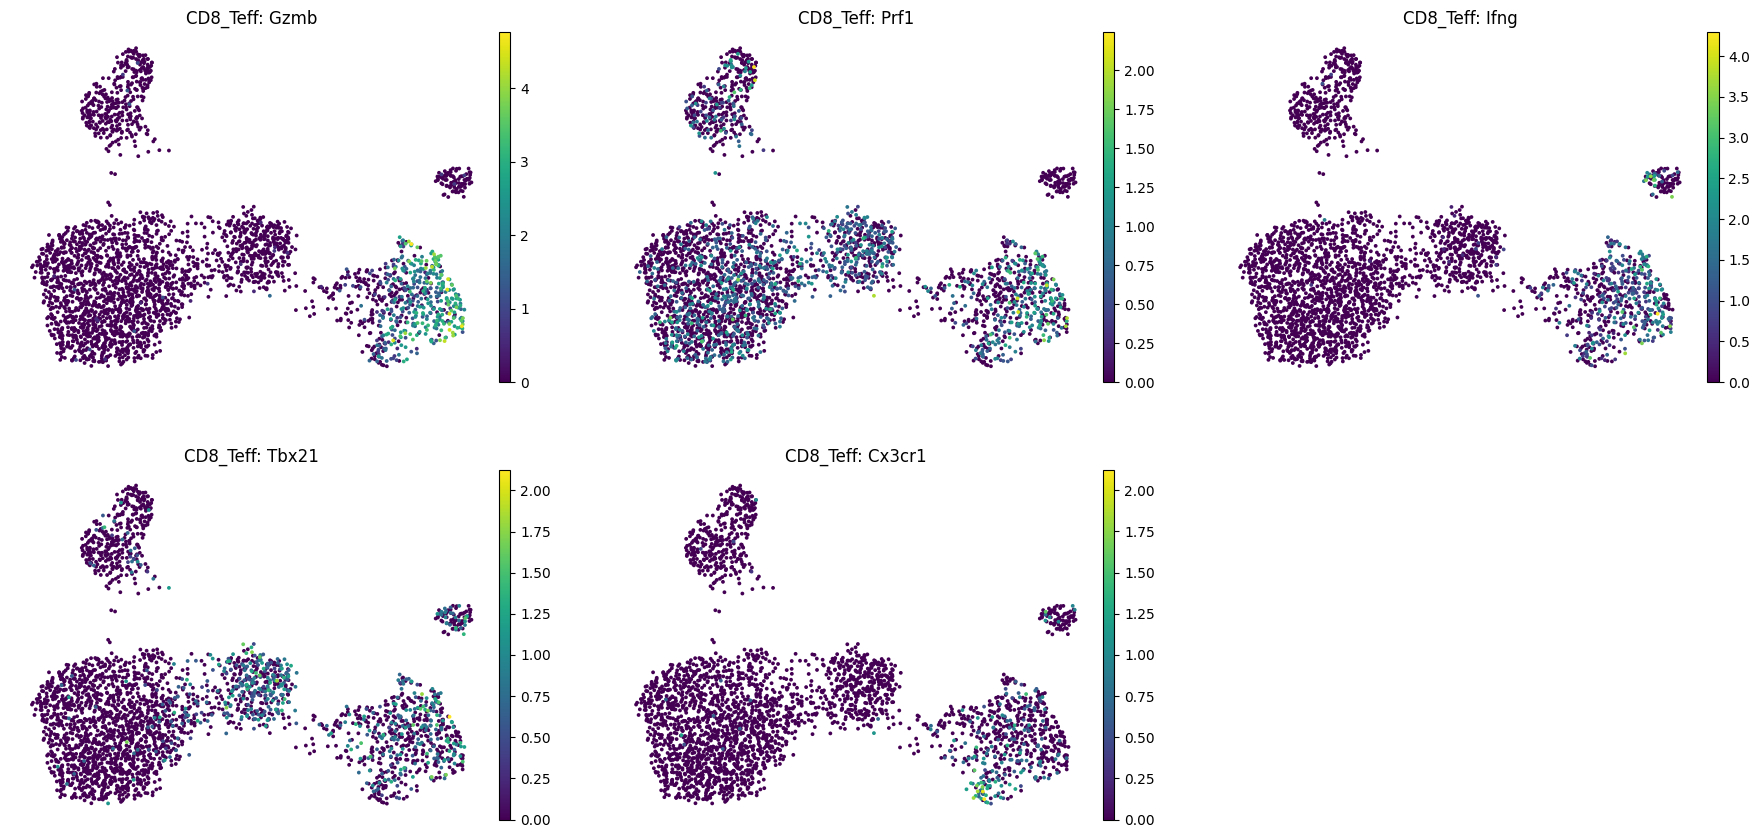

UMAP: CD8_Texh_prog (markers: ['Tcf7', 'Slamf6', 'Xcl1', 'Cd28', 'Cxcr5'])


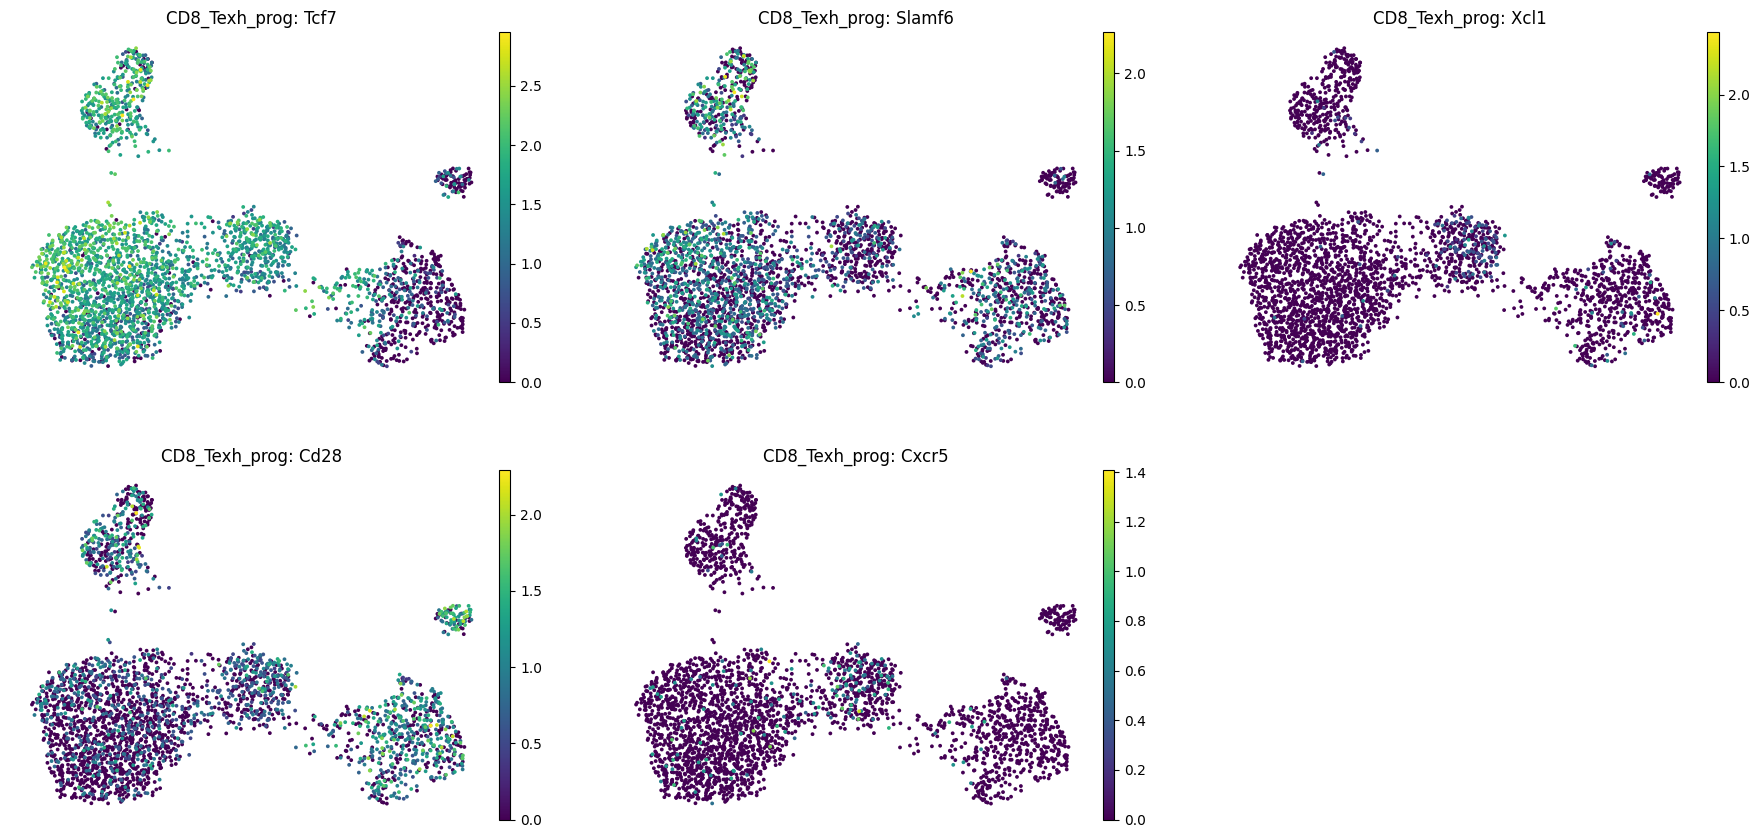

UMAP: CD8_Texh_term (markers: ['Tox', 'Havcr2', 'Lag3', 'Entpd1', 'Ccl3', 'Ccl4'])


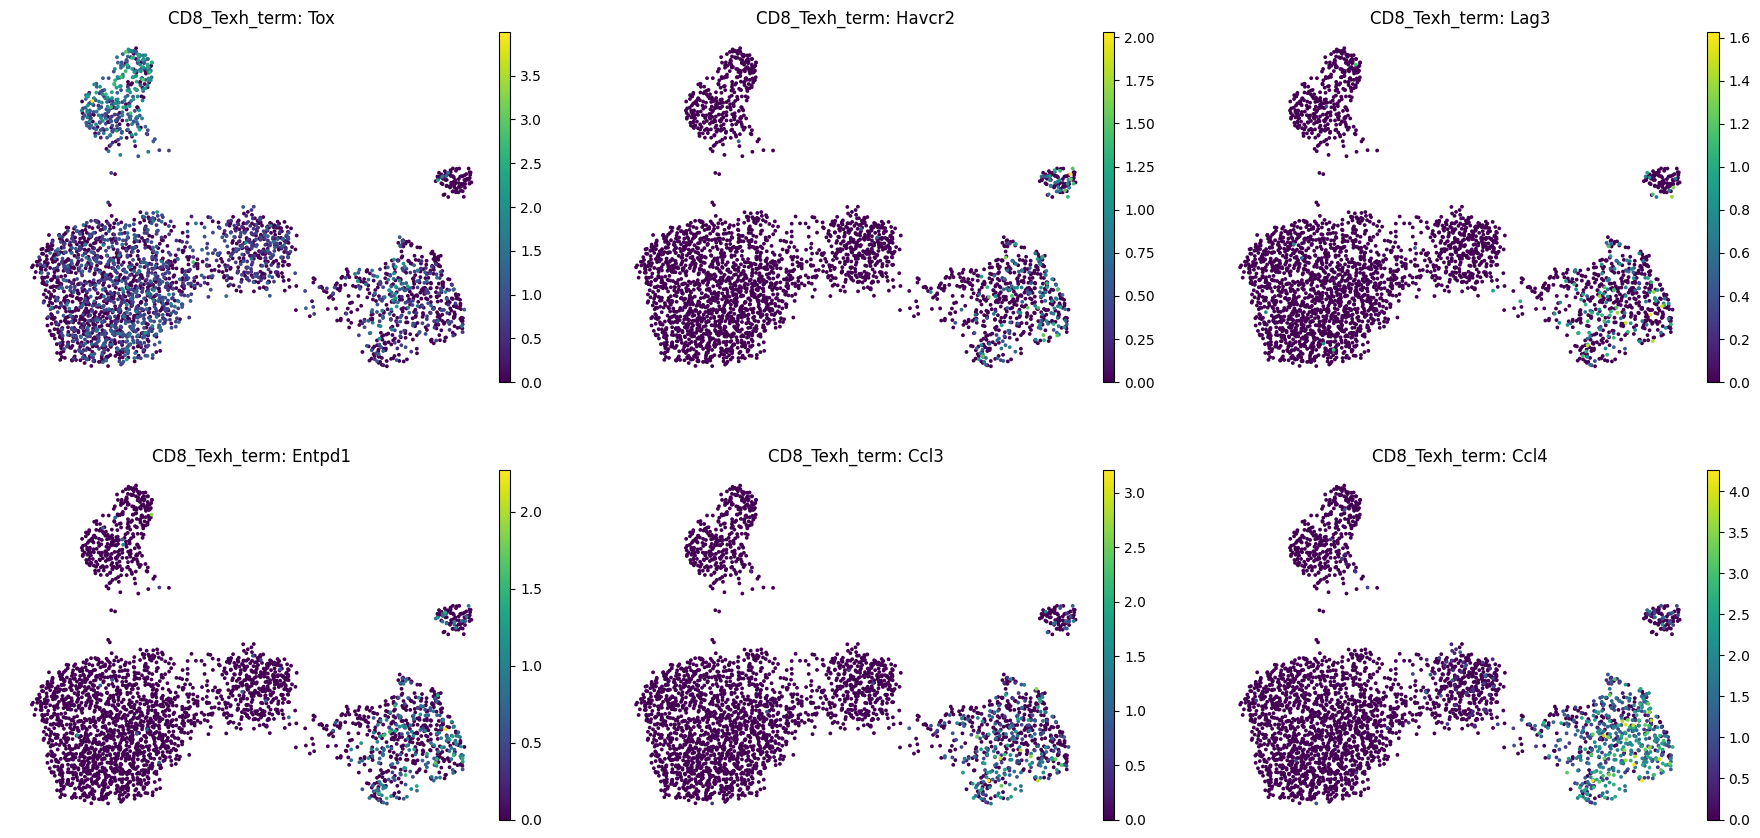

UMAP: CD8_TRM (markers: ['Cd69', 'Itgae', 'Cxcr6'])


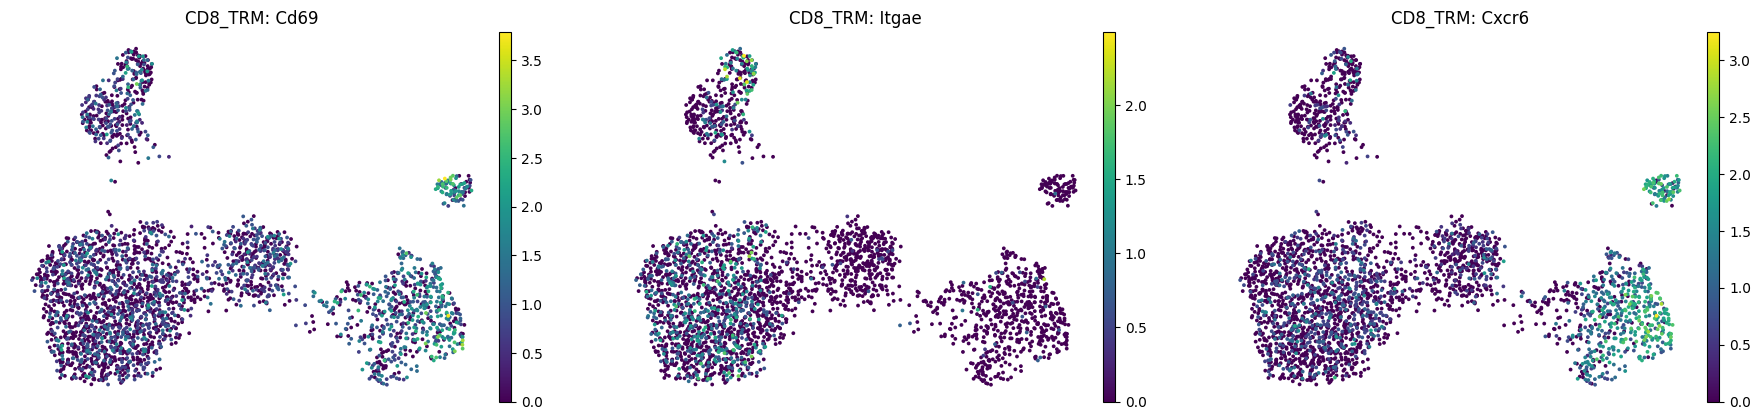

UMAP: CD8_NK_like (markers: ['Klrb1c', 'Klrd1', 'Nkg7', 'Klrk1'])


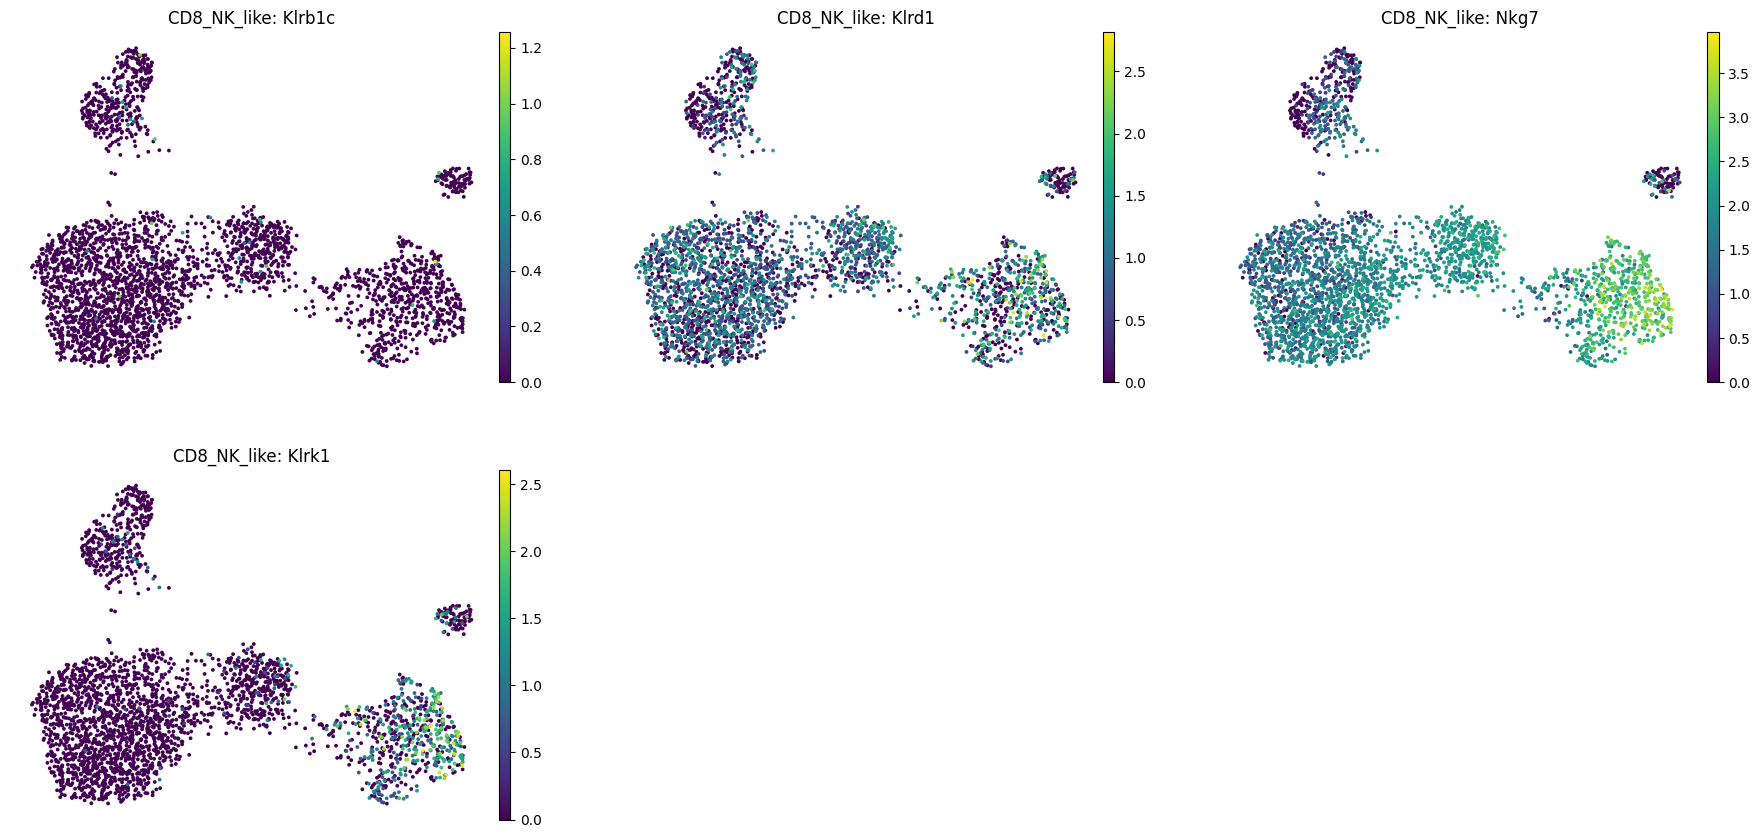

UMAP: CD8_Proliferating (markers: ['Mki67', 'Top2a', 'Pcna', 'Cdk1'])


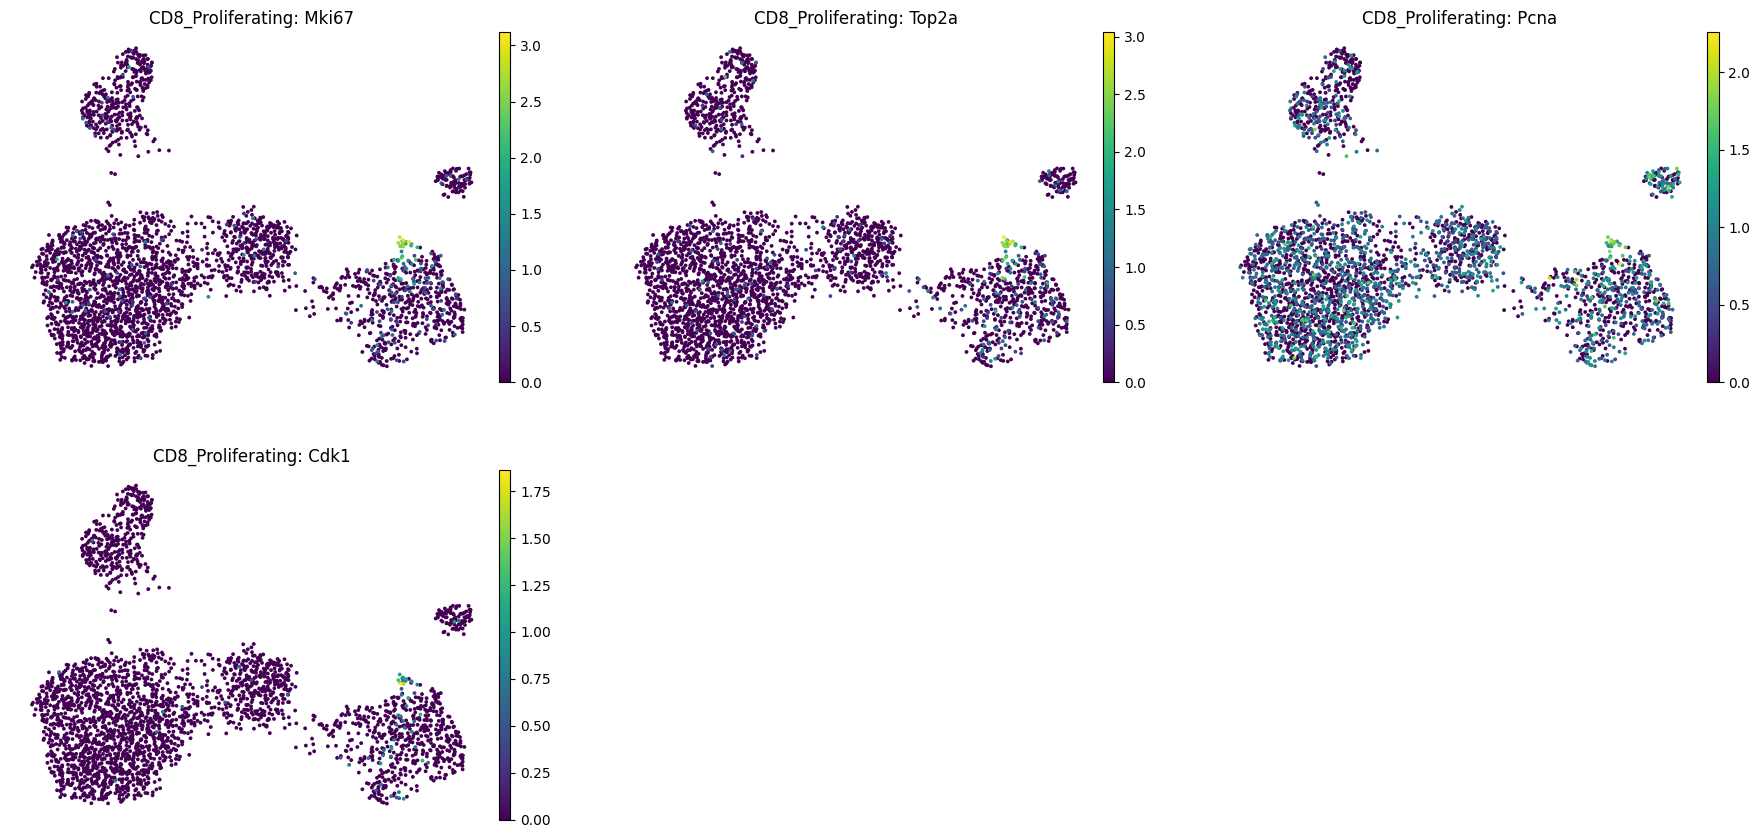

{'CD8_Naive': ['Tcf7', 'Ccr7', 'Il7r', 'Cd28'],
 'CD8_Tem': ['Klrg1', 'Cx3cr1', 'Gzmb', 'Prf1', 'Tbx21'],
 'CD8_Teff': ['Gzmb', 'Prf1', 'Ifng', 'Tbx21', 'Cx3cr1'],
 'CD8_Texh_prog': ['Tcf7', 'Slamf6', 'Xcl1', 'Cd28', 'Cxcr5'],
 'CD8_Texh_term': ['Tox', 'Havcr2', 'Lag3', 'Entpd1', 'Ccl3', 'Ccl4'],
 'CD8_TRM': ['Cd69', 'Itgae', 'Cxcr6'],
 'CD8_NK_like': ['Klrb1c', 'Klrd1', 'Nkg7', 'Klrk1'],
 'CD8_Proliferating': ['Mki67', 'Top2a', 'Pcna', 'Cdk1']}

In [70]:
plot_umap_for_gene_dict(mdata_target['gex'], cd8_state_markers, show=True, save=False)

[Warning] 'CD8_Naive': genes not found in adata: ['Sell']
[Info] Scored 'CD8_Naive': 4 up, 4 down genes.
[Warning] 'CD8_Tem': genes not found in adata: ['Sell-']
[Info] Scored 'CD8_Tem': 5 up, 3 down genes.
[Info] Scored 'CD8_Teff': 5 up, 4 down genes.
[Info] Scored 'CD8_Texh_prog': 5 up, 4 down genes.
[Warning] 'CD8_Texh_term': genes not found in adata: ['Cd101']
[Info] Scored 'CD8_Texh_term': 6 up, 4 down genes.
[Warning] 'CD8_TRM': genes not found in adata: ['Runx3', 'S1pr1-']
[Info] Scored 'CD8_TRM': 3 up, 2 down genes.
[Info] Scored 'CD8_NK_like': 4 up, 2 down genes.
[Info] Scored 'CD8_Proliferating': 4 up, 0 down genes.


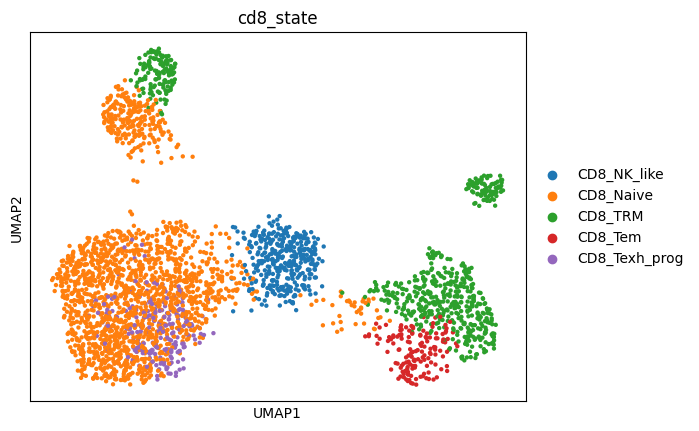

In [71]:
state_scores, state_labels = score_leiden_clusters_by_marker_dict(
    mdata_target['gex'],
    cd8_state_markers,
    cell_type_annotation_col='cd8_state'
)
sc.pl.umap(mdata_target['gex'], color = 'cd8_state')

In [72]:
aa

NameError: name 'aa' is not defined

In [ ]:
# mdata = mdata_utils.sync_mdata_obs(mdata)
leiden_groups = ['1','2','0', '4']
cluster_tissue = {'1': 'CNS', '2': 'CNS', '0': 'CNS',
                  '4': 'SPL'}
leiden_subset = mdata_target.mod['gex'][mdata_target.mod['gex'].obs['leiden'].isin(leiden_groups)].copy()
SPL_cluster = '4'
top_k = 10

sc.tl.rank_genes_groups(
    leiden_subset,
    groupby='leiden',
    groups=leiden_groups,
    reference='rest', 
    method='wilcoxon'
)

sc.pl.rank_genes_groups_dotplot(
    leiden_subset,
    n_genes=top_k,
    groupby='leiden',
)

In [ ]:
import pandas as pd
dfs = []
for grp in leiden_groups:
    df = sc.get.rank_genes_groups_df(leiden_subset, group=grp, pval_cutoff=0.05)
    df['group'] = grp
    dfs.append(df.head(min(150, len(df))))
top_genes_df = pd.concat(dfs, ignore_index=True)

top_genes_df['sample_id'] = selected_id
top_genes_df['group'] = top_genes_df['group'].map(cluster_tissue)

In [ ]:
# df_all = pd.DataFrame()

In [ ]:
top_genes_df.to_csv(selected_id +'_cloned_CD4_DEGs.csv')